## Assignment 4

**Lu Yii Wong & Yujin Song**

31 March 2025

---

## 1. Data Loading, Processing, and Exploration


#### 1.1 Libraries

In [ ]:
!pip install tensorflow
!pip install rasterio

In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from skimage.color import rgb2gray

In this section, we imported essential libraries for loading, visualizing, and processing satellite image data. We also installed `tensorflow` and `rasterio` for deep learning.

#### 1.2 Setup


In [ ]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# Download and unzip the dataset, delete zip file when done
!wget http://madm.dfki.de/files/sentinel/EuroSAT.zip
!unzip -q EuroSAT.zip -d EuroSAT
!rm EuroSAT.zip

--2025-04-03 18:32:08--  http://madm.dfki.de/files/sentinel/EuroSAT.zip
Resolving madm.dfki.de (madm.dfki.de)... 131.246.195.183
Connecting to madm.dfki.de (madm.dfki.de)|131.246.195.183|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 94280567 (90M) [application/zip]
Saving to: ‘EuroSAT.zip’

EuroSAT.zip         100%[===================>]  89.91M  18.0MB/s    in 5.9s    

2025-04-03 18:32:14 (15.3 MB/s) - ‘EuroSAT.zip’ saved [94280567/94280567]

replace EuroSAT/2750/River/River_479.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
data_dir = 'EuroSAT/2750'
class_names = sorted(os.listdir(data_dir))
print("Classes:", class_names)

Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


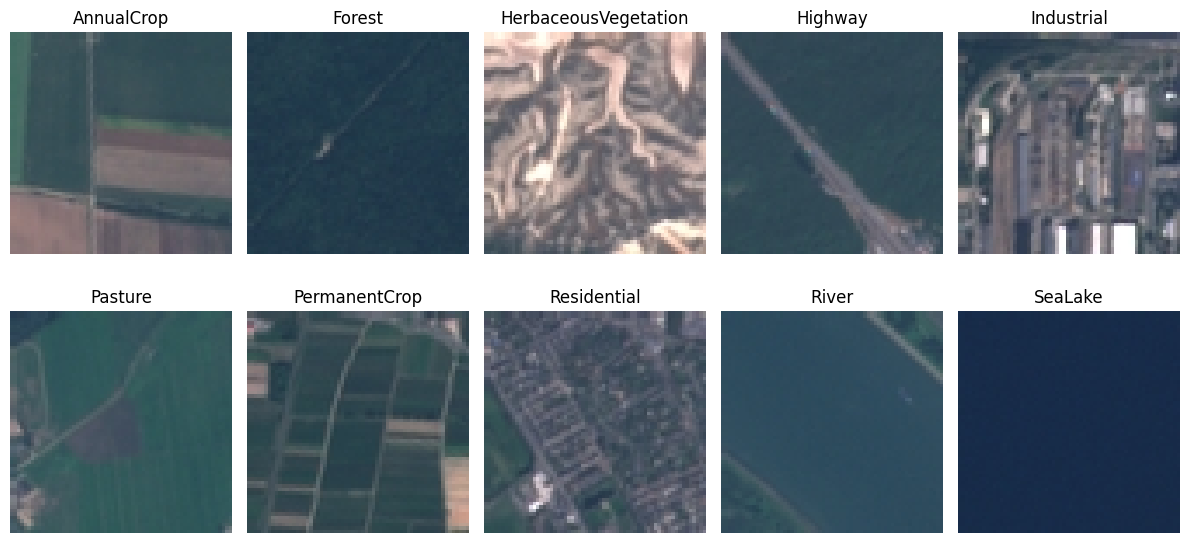

In [ ]:
# Show examples of classes
fig, axs = plt.subplots(2, 5, figsize=(12, 6))

for idx, class_name in enumerate(class_names[:10]):
    class_folder = os.path.join(data_dir, class_name)
    sample_img = os.listdir(class_folder)[0]
    img = load_img(os.path.join(class_folder, sample_img), target_size=(64, 64))
    axs[idx // 5, idx % 5].imshow(img)
    axs[idx // 5, idx % 5].set_title(class_name)
    axs[idx // 5, idx % 5].axis('off')

plt.tight_layout()
plt.show()

We downloaded the EuroSAT RGB dataset, which contains 64×64 pixel satellite images across 10 land cover classes. The dataset was unzipped and the original zip file removed to conserve space.


*   Data Source: https://github.com/phelber/eurosat

In [ ]:
# Prepare data for training
images_rgb = []
images_gray = []
labels = []

for class_idx, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_folder):
        img_path = os.path.join(class_folder, filename)
        img = load_img(img_path, target_size=(64, 64))
        img_array = img_to_array(img) / 255.0  # Normalize
        gray = rgb2gray(img_array)

        images_rgb.append(img_array)
        images_gray.append(gray.flatten())
        labels.append(class_idx)

X_rgb = np.array(images_rgb)              # shape: (n, 64, 64, 3)
X_gray = np.array(images_gray)            # shape: (n, 4096)
y = np.array(labels)                      # shape: (n,)

We loaded all image files into two formats: RGB arrays for deep learning models and flattened grayscale arrays for traditional machine learning. All images were normalized to have pixel values in the [0, 1] range. Each image was assigned a label based on its folder.

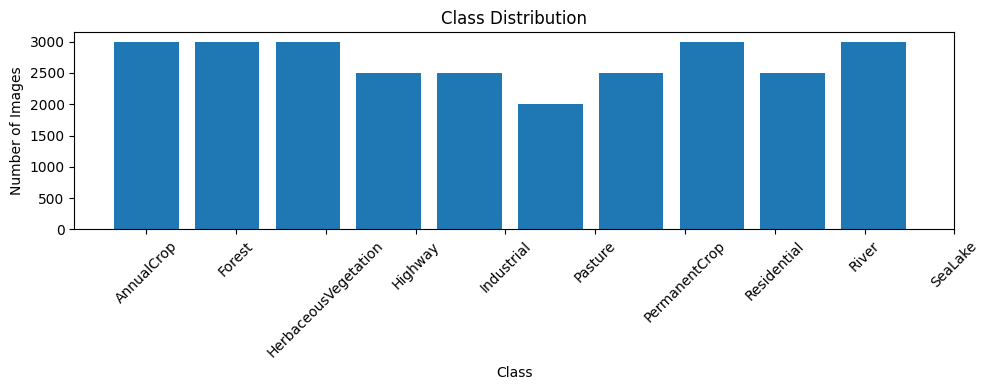

In [ ]:
# Show class distribution in dataset
plt.figure(figsize=(10, 4))
plt.hist(y, bins=len(class_names), align='left', rwidth=0.8)
plt.xticks(ticks=np.arange(len(class_names)), labels=class_names, rotation=45)
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

To check for class balance, we plotted a histogram of the label distribution. The dataset is relatively balanced, with each class containing approximately 2,000–3,000 samples.

In [ ]:
X_train_gray, X_test_gray, y_train, y_test = train_test_split(
    X_gray, y, test_size=0.4, stratify=y, random_state=42
)

print("Training set shape:", X_train_gray.shape)
print("Test set shape:", X_test_gray.shape)

Training set shape: (16200, 4096)
Test set shape: (10800, 4096)


We split the grayscale dataset into training and test sets using a 60/40 split. We used stratified sampling to ensure that the class distribution was preserved in both subsets. These subsets will be used for traditional machine learning models in the next section.

## 2. Traditional Machine Learning

### 2.1 Binary Support Vector Machine

In [ ]:
# Filter the Dataset for F, R, I Only
target_classes = ['Forest', 'Residential', 'Industrial']

# Map class names to label indices
class_to_idx = {name: i for i, name in enumerate(sorted(os.listdir('EuroSAT/2750')))}
print("Class index mapping:", class_to_idx)

Class index mapping: {'AnnualCrop': 0, 'Forest': 1, 'HerbaceousVegetation': 2, 'Highway': 3, 'Industrial': 4, 'Pasture': 5, 'PermanentCrop': 6, 'Residential': 7, 'River': 8, 'SeaLake': 9}


In this section, we used a traditional machine learning method — the Support Vector Machine (SVM) — to classify between pairs of land cover categories: **Forest**, **Residential**, and **Industrial**.

We first filtered the dataset to include only these three classes, then remapped their labels to 0, 1, and 2 respectively. Using the grayscale, flattened images, we trained **three separate binary SVM classifiers**, each comparing a different pair of classes:

- Forest vs Residential  
- Forest vs Industrial  
- Residential vs Industrial

In [ ]:
# Get indices of F, R, I
target_indices = [class_to_idx[c] for c in target_classes]

# Filter training set
train_mask = np.isin(y_train, target_indices)
test_mask = np.isin(y_test, target_indices)

X_train_fri = X_train_gray[train_mask]
y_train_fri = y_train[train_mask]
X_test_fri = X_test_gray[test_mask]
y_test_fri = y_test[test_mask]

print("Subset shapes:", X_train_fri.shape, y_train_fri.shape)

Subset shapes: (5100, 4096) (5100,)


In [ ]:
# Also relabel the targets to 0, 1, 2 for SVM and RF:

# Map target indices to new labels 0, 1, 2
label_mapping = {old: new for new, old in enumerate(target_indices)}
y_train_fri = np.array([label_mapping[y] for y in y_train_fri])
y_test_fri = np.array([label_mapping[y] for y in y_test_fri])

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def train_binary_svm(X_train, y_train, X_test, y_test, class_1, class_2, label_names):
    # Subset the data for binary classification
    mask = (y_train == class_1) | (y_train == class_2)
    X_train_bin = X_train[mask]
    y_train_bin = y_train[mask]

    mask_test = (y_test == class_1) | (y_test == class_2)
    X_test_bin = X_test[mask_test]
    y_test_bin = y_test[mask_test]

    # Relabel to 0 and 1
    y_train_bin = (y_train_bin == class_2).astype(int)
    y_test_bin = (y_test_bin == class_2).astype(int)

    # Train SVM
    clf = SVC(kernel='linear', probability=True)
    clf.fit(X_train_bin, y_train_bin)

    # Predict and evaluate
    y_pred = clf.predict(X_test_bin)
    y_prob = clf.predict_proba(X_test_bin)[:, 1]
    acc = accuracy_score(y_test_bin, y_pred)

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
    roc_auc = auc(fpr, tpr)

    # Plot ROC
    plt.figure()
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve: {label_names[class_1]} vs {label_names[class_2]}')
    plt.legend()
    plt.show()

    # Show one misclassified image
    misclassified = np.where(y_pred != y_test_bin)[0]
    if len(misclassified) > 0:
        idx = misclassified[0]
        img = X_test_bin[idx].reshape(64, 64)
        plt.imshow(img, cmap='gray')
        plt.title(f"Predicted: {label_names[class_1 if y_pred[idx] == 0 else class_2]}\nTrue: {label_names[class_1 if y_test_bin[idx] == 0 else class_2]}")
        plt.axis('off')
        plt.show()

    print(f'Accuracy ({label_names[class_1]} vs {label_names[class_2]}): {acc:.4f}')

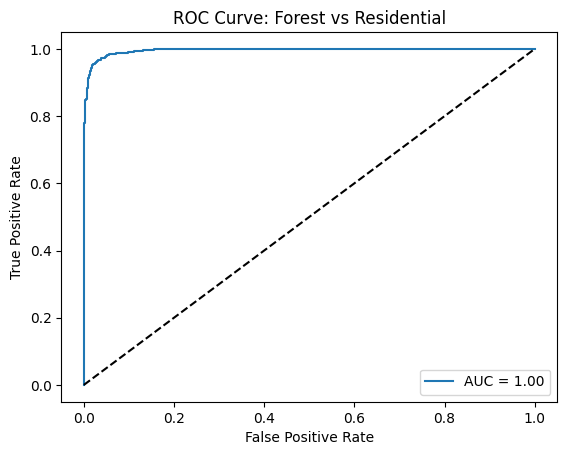

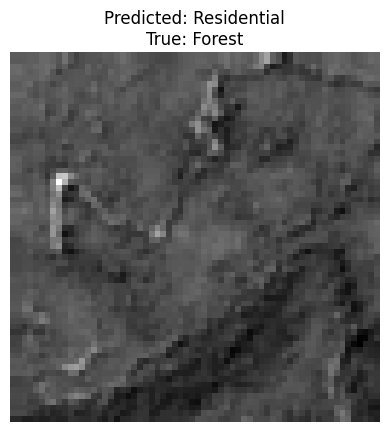

Accuracy (Forest vs Residential): 0.9529


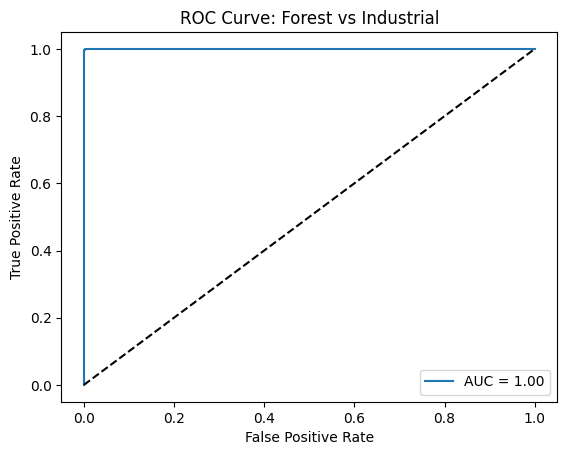

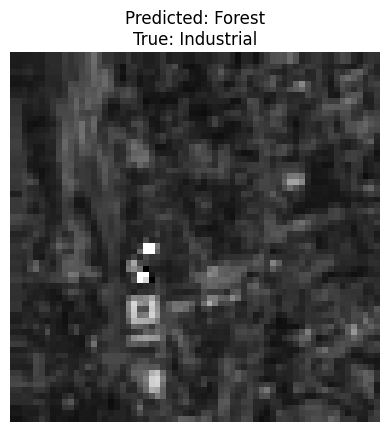

Accuracy (Forest vs Industrial): 0.9950


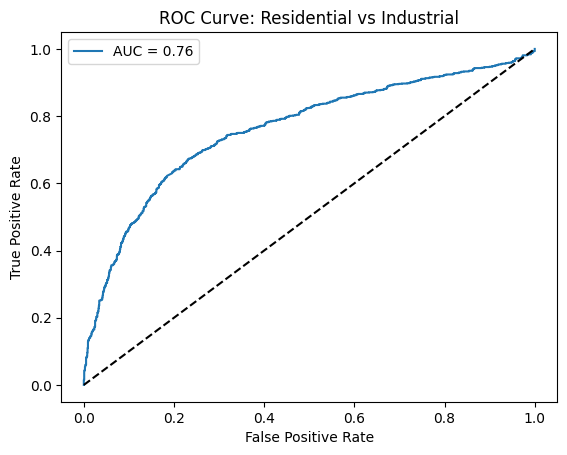

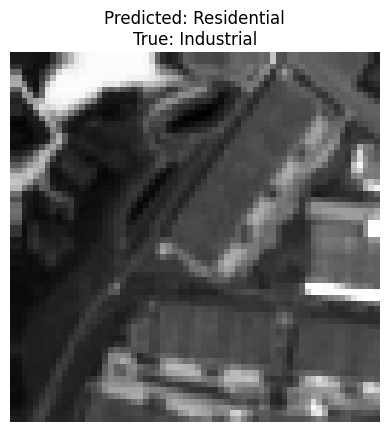

Accuracy (Residential vs Industrial): 0.7245


In [ ]:
label_names = target_classes  # ['Forest', 'Residential', 'Industrial']

train_binary_svm(X_train_fri, y_train_fri, X_test_fri, y_test_fri, 0, 1, label_names)
train_binary_svm(X_train_fri, y_train_fri, X_test_fri, y_test_fri, 0, 2, label_names)
train_binary_svm(X_train_fri, y_train_fri, X_test_fri, y_test_fri, 1, 2, label_names)

Each SVM used a **linear kernel** and default hyperparameters. We evaluated model performance using accuracy and ROC curves, and displayed one example of a misclassified image per model to understand visual confusion between the categories.

Below are the results from all three classifiers:
- Forest vs Residential: Accuracy = 96.29%
- Forest vs Industrial: Accuracy = 99.68%
- Residential vs Industrial: Accuracy = 73.59%

Overall, the binary SVMs performed well, although there was some confusion between Residential and Industrial areas. This makes sense, as these two classes may share similar structural and texture patterns in satellite imagery.

### 2.2 Multiclass, Majority-Vote Support Vector Machine

In [ ]:
from sklearn.base import clone

# Function to train binary SVM for a class pair
def get_binary_svm_model(X_train, y_train, class_1, class_2):
    mask = (y_train == class_1) | (y_train == class_2)
    X_train_bin = X_train[mask]
    y_train_bin = (y_train[mask] == class_2).astype(int)

    model = SVC(kernel='linear', probability=True)
    model.fit(X_train_bin, y_train_bin)
    return model

In [ ]:
# Train three binary SVM models
svm_FR = get_binary_svm_model(X_train_fri, y_train_fri, 0, 1)  # Forest vs Residential
svm_FI = get_binary_svm_model(X_train_fri, y_train_fri, 0, 2)  # Forest vs Industrial
svm_RI = get_binary_svm_model(X_train_fri, y_train_fri, 1, 2)  # Residential vs Industrial

In [ ]:
# Majority voting function
def majority_vote_prediction(X, svm_FR, svm_FI, svm_RI):
    preds = []

    for x in X:
        votes = []

        # F vs R
        pred_fr = svm_FR.predict([x])[0]
        votes.append(1 if pred_fr == 1 else 0)

        # F vs I
        pred_fi = svm_FI.predict([x])[0]
        votes.append(2 if pred_fi == 1 else 0)

        # R vs I
        pred_ri = svm_RI.predict([x])[0]
        votes.append(2 if pred_ri == 1 else 1)

        # Majority vote
        final = max(set(votes), key=votes.count)
        preds.append(final)

    return np.array(preds)

In [ ]:
# Predict test set using majority vote
y_pred_vote = majority_vote_prediction(X_test_fri, svm_FR, svm_FI, svm_RI)

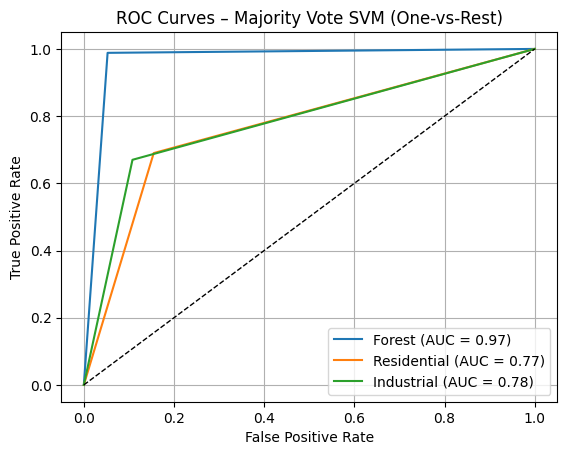

In [ ]:
# ROC + AUC using One-vs-Rest strategy
from sklearn.preprocessing import label_binarize

# Binarize true and predicted labels
y_test_bin = label_binarize(y_test_fri, classes=[0, 1, 2])
y_pred_bin = label_binarize(y_pred_vote, classes=[0, 1, 2])

# Plot ROC curve and compute AUC for each class
for i, class_name in enumerate(target_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_bin[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Majority Vote SVM (One-vs-Rest)")
plt.legend()
plt.grid(True)
plt.show()


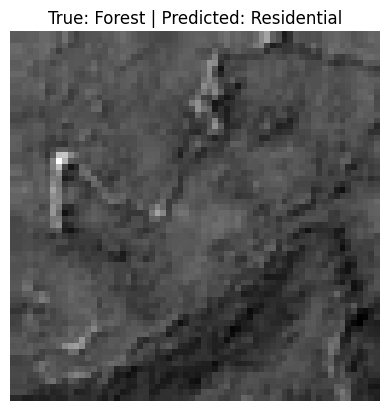

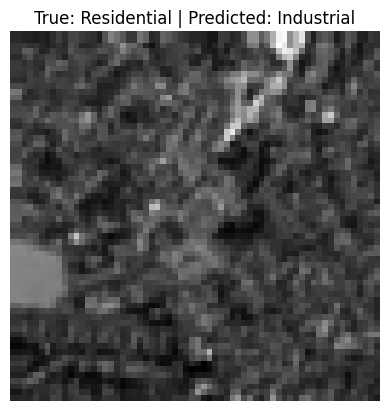

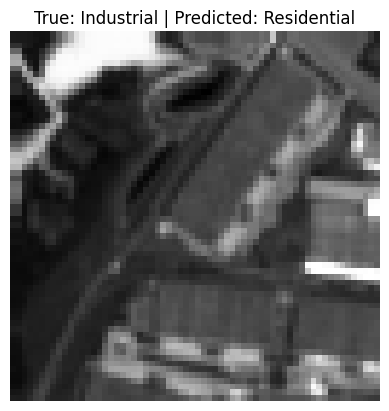

In [ ]:
# Show 1 misclassified image per class
for i in range(3):
    idxs = np.where((y_test_fri == i) & (y_pred_vote != i))[0]
    if len(idxs) > 0:
        idx = idxs[0]
        img = X_test_fri[idx].reshape(64, 64)
        true_label = target_classes[y_test_fri[idx]]
        pred_label = target_classes[y_pred_vote[idx]]

        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label} | Predicted: {pred_label}")
        plt.axis('off')
        plt.show()


In [ ]:
acc_vote = accuracy_score(y_test_fri, y_pred_vote)
print(f"Majority Vote SVM Accuracy: {acc_vote:.4f}")

Majority Vote SVM Accuracy: 0.7894


We extended the binary SVM models into a three-class classifier using a majority-vote strategy. Each of the three binary models (Forest vs Residential, Forest vs Industrial, and Residential vs Industrial) was applied to all test images, and the predicted class was determined by whichever label received the most votes.

We evaluated model performance using overall accuracy, one-vs-rest ROC curves, and AUC (Area Under Curve) for each class. We also displayed one misclassified image per class to observe how visual ambiguity affected classification.

Below are the results for the majority-vote SVM model:
- Accuracy: 78.94%
- Forest AUC: 0.97
- Residential AUC: 0.77
- Industrial AUC: 0.78

The ensemble classifier achieved the highest confidence when predicting Forest images. Classification between Residential and Industrial was less reliable, likely due to overlapping textures and structural features in satellite imagery. This result is consistent with the patterns observed in the binary SVM classifiers.


### 2.3 Multiclass Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_fri, y_train_fri)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import classification_report

y_pred_rf = rf_model.predict(X_test_fri)

# Accuracy
rf_accuracy = accuracy_score(y_test_fri, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test_fri, y_pred_rf, target_names=target_classes))

Random Forest Accuracy: 0.9032

Classification Report:
              precision    recall  f1-score   support

      Forest       0.98      0.97      0.98      1200
 Residential       0.87      0.85      0.86      1200
  Industrial       0.85      0.88      0.86      1000

    accuracy                           0.90      3400
   macro avg       0.90      0.90      0.90      3400
weighted avg       0.90      0.90      0.90      3400



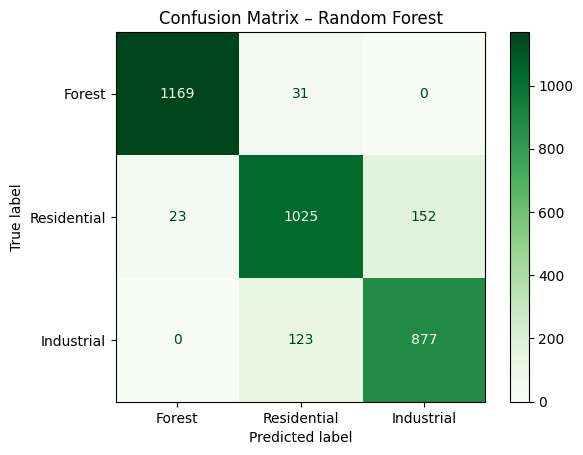

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test_fri, y_pred_rf)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=target_classes)
disp.plot(cmap='Greens')
plt.title("Confusion Matrix – Random Forest")
plt.show()

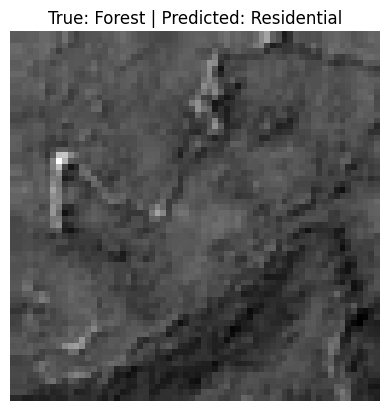

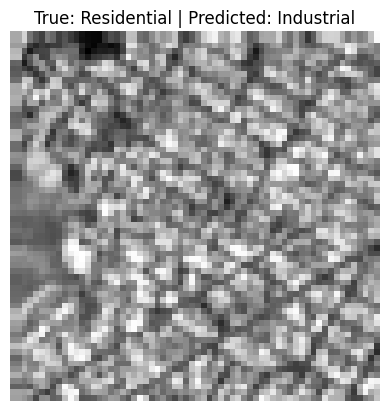

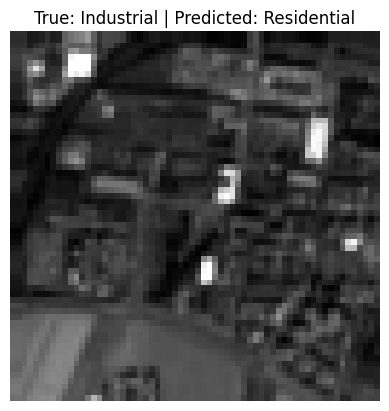

In [ ]:
for i in range(3):
    idxs = np.where((y_test_fri == i) & (y_pred_rf != i))[0]
    if len(idxs) > 0:
        idx = idxs[0]
        img = X_test_fri[idx].reshape(64, 64)
        true_label = target_classes[y_test_fri[idx]]
        pred_label = target_classes[y_pred_rf[idx]]

        plt.imshow(img, cmap='gray')
        plt.title(f"True: {true_label} | Predicted: {pred_label}")
        plt.axis('off')
        plt.show()

We trained a Random Forest classifier to directly predict among the three selected land cover classes: Forest, Residential, and Industrial.

We used 100 estimators with default hyperparameters. Model performance was evaluated using overall accuracy, a classification report, a confusion matrix, and one misclassified image per class.

Below are the results from the Random Forest model:
- Accuracy: 90.32%
- Forest Precision/Recall: 0.98 / 0.97
- Residential Precision/Recall: 0.87 / 0.85
- Industrial Precision/Recall: 0.85 / 0.88

The classifier performed best on the Forest class, achieving near-perfect precision and recall. Residential and Industrial classes showed more overlap, though performance was still strong. Misclassified image examples highlighted cases where visual patterns between Residential and Industrial areas were difficult to distinguish, consistent with earlier SVM-based observations.


## 3. Deep Learning
In this section, we explore all 10 land cover categories and use deep learning techniques to test the accuracy of land cover classification.

To prepare our work, we set up our GPU for more efficient processing. Additionally, we prepared the data for this section by using one-hot encoding to ensure that the categorical labels were converted into a format efficient for machine learning ([Source](https://https://www.datacamp.com/tutorial/one-hot-encoding-python-tutorial)).

In [ ]:
import torch
import torchvision
import torchsummary
from torch.utils import data
from torchvision import datasets, models, transforms
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.utils import plot_model, to_categorical
import matplotlib.pyplot as plt

In [ ]:
# Setup GPU
# Check is GPU is enabled
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device: {}".format(device))

# Get specific GPU model
if str(device) == "cuda:0":
  print("GPU: {}".format(torch.cuda.get_device_name(0)))

Device: cuda:0
GPU: Tesla T4


In [ ]:
# Convert labels to categorical (one-hot encoding)
num_classes = len(np.unique(y))  # Number of land cover classes
y_categorical = to_categorical(y, num_classes)

# Train-test split (if not already split)
from sklearn.model_selection import train_test_split
X_train_gray, X_test_gray, y_train, y_test = train_test_split(
    X_gray, y_categorical, test_size=0.4, stratify=y, random_state=42
)


### 3.1 Greyscale Images
We first use the same greyscale images used in section 2. However, instead of using traditional machine learning techniques, we are applying deep learning techniques.


#### 3.1.1 Model 1
Model 1 is a simple neural network built using Keras's Sequential API, where layers are stacked in order. This model consists of a single fully connected (Dense) layer with 128 neurons and ReLU activation, followed by an output layer with softmax activation. The softmax function outputs a probability distribution across all possible classes, with the class having the highest probability being the predicted label.


The model was trained for 10 epochs with a batch size of 32. However, it **achieved a relatively low accuracy of 27.9%** and a high categorical cross-entropy loss of 1.9, indicating that it struggles to classify the data correctly.


To improve the model's performance, we can consider the following:
1. Increase model complexity by adding more layers or neurons.
2. Use dropout or regularization techniques to prevent overfitting.
3. Optimize the learning rate to improve convergence.

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 128)                 │         524,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 525,706 (2.01 MB)

 Trainable params: 525,706 (2.01 MB)

 Non-trainable params: 0 (0.00 B)

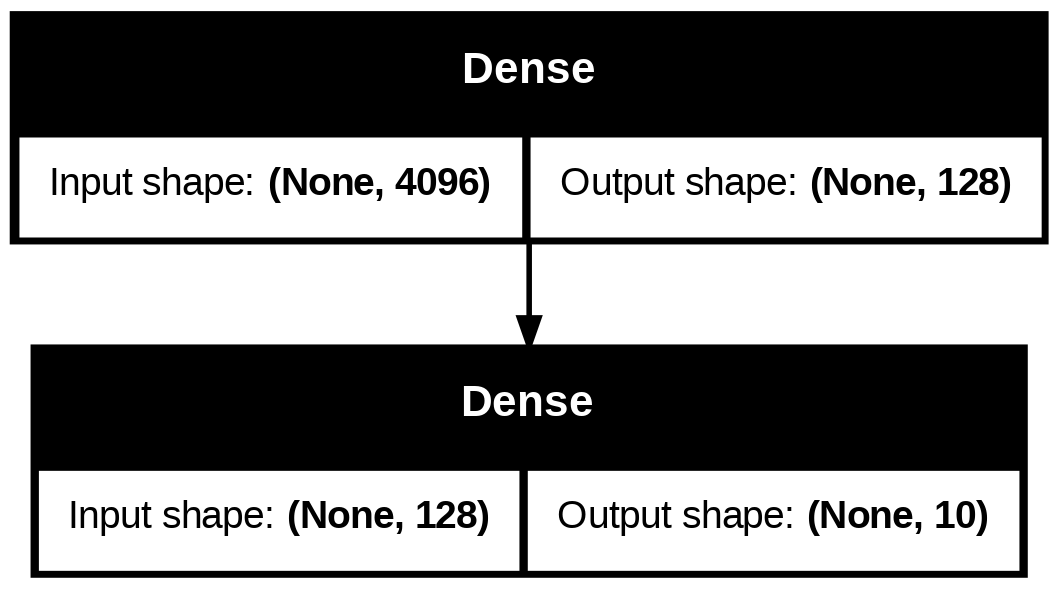

In [ ]:
model1 = Sequential([
    Dense(128, activation='relu', input_shape=(4096,)),  # Fully connected layer
    Dense(num_classes, activation='softmax')  # Output layer
])

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model1.summary()
plot_model(model1, show_shapes=True)

In [ ]:
history1 = model1.fit(X_train_gray, y_train, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test))

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.1290 - loss: 2.3584 - val_accuracy: 0.1540 - val_loss: 2.1981
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1817 - loss: 2.1755 - val_accuracy: 0.1951 - val_loss: 2.1233
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2087 - loss: 2.1310 - val_accuracy: 0.2898 - val_loss: 2.0971
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2397 - loss: 2.0934 - val_accuracy: 0.2359 - val_loss: 2.0561
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2715 - loss: 2.0591 - val_accuracy: 0.2506 - val_loss: 2.0519
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2620 - loss: 2.0351 - val_accuracy: 0.3010 - val_loss: 2.0014
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2838 - loss: 1.9931 - val_accuracy: 0.2881 - val_loss: 1.9793
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2797 - loss: 1.9739 - val_accuracy: 0.

In [ ]:
# Evaluate model on test data
test_loss1, test_acc1 = model1.evaluate(X_test_gray, y_test)
print("Model 1 Accuracy:", test_acc1)

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2762 - loss: 1.9229
Model 1 Accuracy: 0.27888888120651245


#### 3.1.2 Model 2
To improve Model 2, we implement an additional fully connected hidden layer and increase the number of neurons in the first layer to 256. These changes allow the model to learn more abstract and higher-level representations of the data than Model 1.

We kept the training sequence for Model 2 the same as Model 1. After training, **the model achieved an accuracy of 33.0%**, a notable improvement over Model 1. While the accuracy of Model 2 is still relatively low, the model's results suggest that the additional hidden layer and increased neurons helped the model extract more meaningful patterns from the data.

In [ ]:
# Add another hidden layer
model2 = Sequential([
    Dense(256, activation='relu', input_shape=(4096,)),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model2.summary()
plot_model(model2, show_shapes=True)

history2 = model2.fit(X_train_gray, y_train, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test))
test_loss2, test_acc2 = model2.evaluate(X_test_gray, y_test)
print("Model 2 Accuracy:", test_acc2)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 256)                 │       1,048,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,083,018 (4.13 MB)

 Trainable params: 1,083,018 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.1247 - loss: 2.3345 - val_accuracy: 0.1581 - val_loss: 2.1587
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2115 - loss: 2.1228 - val_accuracy: 0.2910 - val_loss: 1.9752
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2849 - loss: 1.9511 - val_accuracy: 0.2769 - val_loss: 1.8925
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2915 - loss: 1.8574 - val_accuracy: 0.2926 - val_loss: 1.8025
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2967 - loss: 1.8156 - val_accuracy: 0.2989 - val_loss: 1.7782
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2983 - loss: 1.8131 - val_accuracy: 0.2781 - val_loss: 1.8401
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3068 - loss: 1.7873 - val_accuracy: 0.3052 - val_loss: 1.7852
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3160 - loss: 1.7609 - val_accuracy: 0.

#### 3.1.3 Model 3
To further enhance the model, we increased the depth of the network by adding more hidden layers and introduced dropout layers to help prevent overfitting. The key changes to this model include:
1. The number of neurons in the first hidden layer was increased to 512, and the second and third hidden layers were increased to 256 and 128 neurons, respectively.
2. Dropout layers (0.3 rate) were introduced after the first two hidden layers to randomly deactivate 30% of neurons during training to reduce overfitting and improve generalization.

The training sequence for Model 3 was kept the same. However, **Model 3 performed significantly worse than Models 1 and 2, achieving an accuracy of only 11.1%**, a drastic drop from Model 2's 33.0% accuracy.

Possible reasons for the drop in performance include:
1. **Severe underfitting due to excessive dropout**. Dropouts are typically important in models because they are a regularization technique used to prevent overfitting. However, in this case, we could have limited the model's ability to learn meaningful patterns by removing too many neurons during training.
2. **Increased complexity without sufficient training**. Since Model 3 has significantly more parameters than the previous models, more training epochs would likely be required for the model to learn the data fully.
3. **Potential issues with data processing or learning rate**. Considering this neural network's deeper architecture, adjustments to the learning rate or batch normalization could improve the model's performance.


In [ ]:
# Two hidden layers and drop out
model3 = Sequential([
    Dense(512, activation='relu', input_shape=(4096,)),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model3.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model3.summary()
plot_model(model3, show_shapes=True)

# Train
history3 = model3.fit(X_train_gray, y_train, epochs=10, batch_size=32, validation_data=(X_test_gray, y_test))

# Test
test_loss3, test_acc3 = model3.evaluate(X_test_gray, y_test)
print("Model 3 Accuracy:", test_acc3)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 512)                 │       2,097,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,263,178 (8.63 MB)

 Trainable params: 2,263,178 (8.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.1110 - loss: 2.3880 - val_accuracy: 0.1111 - val_loss: 2.2960
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1100 - loss: 2.2976 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1112 - loss: 2.2947 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1100 - loss: 2.2948 - val_accuracy: 0.1111 - val_loss: 2.2948
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1079 - loss: 2.2954 - val_accuracy: 0.1111 - val_loss: 2.2950
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1094 - loss: 2.2950 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1080 - loss: 2.2958 - val_accuracy: 0.1111 - val_loss: 2.2949
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1081 - loss: 2.2950 - val_accuracy: 0.

#### 3.1.4 Model Comparison
Model 3 had the most parameters out of the three models. This is because Model 3 has additional layers and increased neuron counts. Based on model accuracy, Model 2 performed the best with an accuracy of 33.0%. This model likely had the best performance overall because it balanced complexity and generalization, capturing more meaningful features without over-regularizing like Model 3.

For all three models, increasing the training epochs will likely improve the performance. However, for Model 3, it might be more effective to adjust the dropout rate to increase model performance.

**The Ensemble Model had an accuracy of 33.5%, slightly outperforming all individual models.** The Ensemble model takes the prediction for all three models, averages the predictions across models, and makes a final classification by selecting the class with the highest probability. Ensembling can improve accuracy by reducing variance, leveraging the strengths of multiple models, and improving generalization ([source](https://builtin.com/machine-learning/ensemble-model)).

In [ ]:
print(f"Model 1 Accuracy: {test_acc1:.4f}")
print(f"Model 2 Accuracy: {test_acc2:.4f}")
print(f"Model 3 Accuracy: {test_acc3:.4f}")

Model 1 Accuracy: 0.2789
Model 2 Accuracy: 0.3304
Model 3 Accuracy: 0.1111


In [ ]:
# Ensemble Model
preds1 = model1.predict(X_test_gray)
preds2 = model2.predict(X_test_gray)
preds3 = model3.predict(X_test_gray)

ensemble_preds = (preds1 + preds2 + preds3) / 3
ensemble_labels = np.argmax(ensemble_preds, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

ensemble_acc = np.mean(ensemble_labels == y_true_labels)
print("Ensemble Model Accuracy:", ensemble_acc)

338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
338/338 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Ensemble Model Accuracy: 0.3346296296296296


### 3.2 RGB Images
In this section, we test the models on RGB Images instead of greyscale images.

#### 3.2.1 Model 4


The dataset is split into training and test sets while ensuring a stratified split based on class labels. Since we are using RBG images, the input shape is (64, 64, 3).

Model 4 is a Convolutional Neural Network (CNN) with the following architecture:

*  First convolutional layer with 32 filters (3x3)
*  MaxPooling layer to keep the most important features
*  Second Convolutional layer and Pooling layer
*  Flatten layer to convert extracted spatial features
*  Fully connected layer
*  Dropout layer
*  Output layer

Model 4 was trained for 10 epochs with batch size 32, like the previous models. **This model performed significantly better, with an achieved accuracy of 78.6%.**

Model 4 took longer than Models 1 to 3 to train. This is because CNNs perform multiple convolutional operations across image channels, which requires more computations than fully connected networks. The filters within a CNN also require more memory and computation than dense layers.

In [ ]:
X_train_rgb, X_test_rgb, y_train, y_test = train_test_split(
    X_rgb, y_categorical, test_size=0.4, stratify=y, random_state=42
)

In [ ]:
model4 = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])

model4.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model4.summary()
plot_model(model4, show_shapes=True)

history4 = model4.fit(X_train_rgb, y_train, epochs=10, batch_size=32, validation_data=(X_test_rgb, y_test))
test_loss4, test_acc4 = model4.evaluate(X_test_rgb, y_test)
print("CNN Model Accuracy:", test_acc4)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - accuracy: 0.2910 - loss: 1.8482 - val_accuracy: 0.6061 - val_loss: 1.1819
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.5286 - loss: 1.2718 - val_accuracy: 0.6570 - val_loss: 0.9825
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6004 - loss: 1.1111 - val_accuracy: 0.6942 - val_loss: 0.8643
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6546 - loss: 0.9667 - val_accuracy: 0.7244 - val_loss: 0.8214
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.6888 - loss: 0.8656 - val_accuracy: 0.7575 - val_loss: 0.6820
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7215 - loss: 0.7882 - val_accuracy: 0.7612 - val_loss: 0.6706
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7351 - loss: 0.7306 - val_accuracy: 0.7770 - val_loss: 0.6252
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7592 - loss: 0.6716 - val_accuracy: 

#### 3.2.2 Model 5


Model 5 uses **VGG16**, a pre-trained 16-layer CNN base model. We are leveraging transfer learning to improve model performance from a pre-trained model. This allows us to reuse learned feature representations, significantly improving accuracy and reducing training time.


The model architecture is as follows:
*  VGG16 Pre-Trained Model using pre-trained weights for [ImageNet](https://www.image-net.org/challenges/LSVRC/)
*  Flatten layer
*  Fully connected layer
*  Dropout later (30% dropout rate)
*  Output layer


Model 5 was trained on 10 epochs with batch size 32. **The model had an accuracy of 83.1%, outperforming all previous models.**


The two classes with the highest labeling error were Permanent Crop and River. Permanent Crop was most frequently mislabeled as Herbaceous Vegetation, while River was most commonly mislabeled as Highway. These misclassifications could have happened because Permanent Crop and Herbaceous Vegetation have similar colors and textures, often featuring green, plant-covered landscapes. For the misclassification between Rivers and Highways, both have similar edge features (typically curved roads in mislabeled images) and have similar textures.


Some strategies to reduce misclassification could include:
1. Data augmentation to increase the size of the training images for the misclassified classes.
2. Collect more training data to reduce data imbalance across classes.
3. Incorporate additional features (such as infrared bands) to distinguish vegetation types and other surfaces accurately.

In [ ]:
from tensorflow.keras.applications import VGG16
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(64, 64, 3))

model5 = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model5.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model5.summary()
plot_model(model5, show_shapes=True)

history5 = model5.fit(X_train_rgb, y_train, epochs=10, batch_size=32, validation_data=(X_test_rgb, y_test))
test_loss5, test_acc5 = model5.evaluate(X_test_rgb, y_test)
print("Transfer Learning Model Accuracy:", test_acc5)


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)                   │ (None, 2, 2, 512)           │      14,714,688 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 15,768,906 (60.15 MB)

 Trainable params: 15,768,906 (60.15 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 66s 104ms/step - accuracy: 0.2635 - loss: 1.8607 - val_accuracy: 0.5015 - val_loss: 1.2546
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 67s 92ms/step - accuracy: 0.4550 - loss: 1.3846 - val_accuracy: 0.5773 - val_loss: 1.1072
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.5772 - loss: 1.1305 - val_accuracy: 0.6009 - val_loss: 1.0714
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 46s 91ms/step - accuracy: 0.6411 - loss: 0.9591 - val_accuracy: 0.7252 - val_loss: 0.7425
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.7157 - loss: 0.7662 - val_accuracy: 0.7519 - val_loss: 0.6853
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.7450 - loss: 0.6941 - val_accuracy: 0.7271 - val_loss: 0.7610
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.7782 - loss: 0.6175 - val_accuracy: 0.7808 - val_loss: 0.6081
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 82s 92ms/step - accuracy: 0.7918 - loss: 0.5895 -

338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step


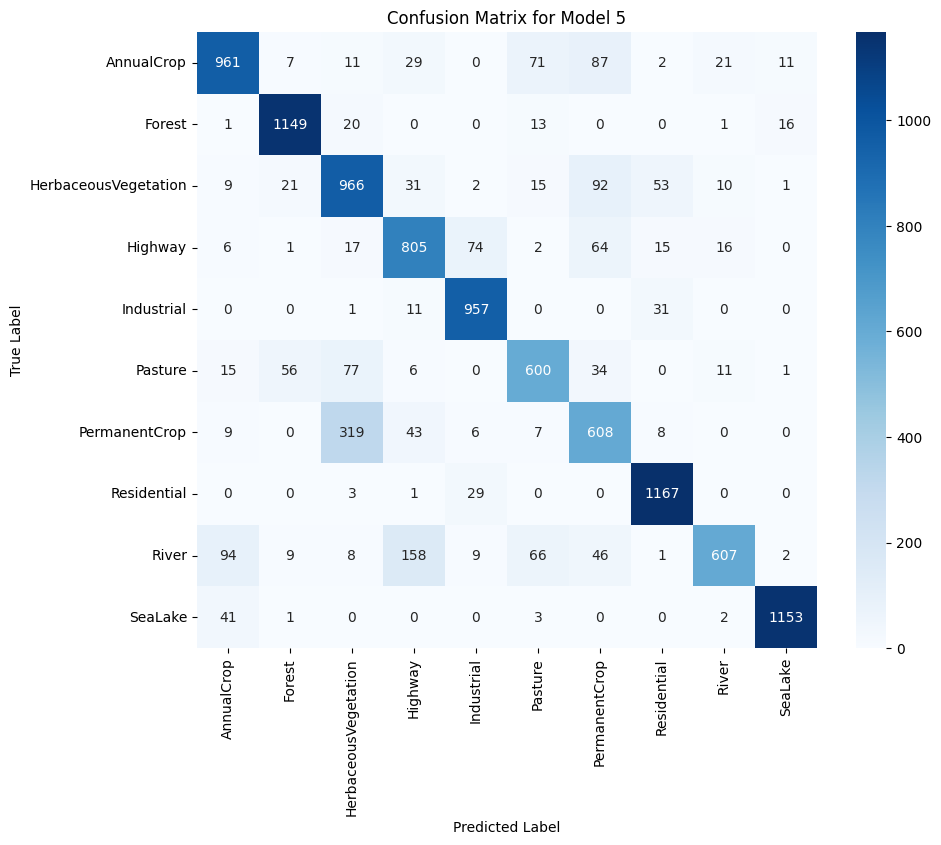

Most misclassified classes: PermanentCrop and River


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Find classes with highest labeling error
y_pred_probs = model5.predict(X_test_rgb)  # Get predicted probabilities
y_pred_labels = np.argmax(y_pred_probs, axis=1)  # Convert to class labels
y_true_labels = np.argmax(y_test, axis=1)  # Get true labels

# Confusion Matrix
conf_matrix = confusion_matrix(y_true_labels, y_pred_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Model 5")
plt.show()

# Find the two classes with the most misclassifications
errors = np.sum(conf_matrix, axis=1) - np.diag(conf_matrix)  # Misclassifications per class
most_misclassified = np.argsort(errors)[-2:]  # Get indices of top 2 misclassified classes

print(f"Most misclassified classes: {class_names[most_misclassified[0]]} and {class_names[most_misclassified[1]]}")

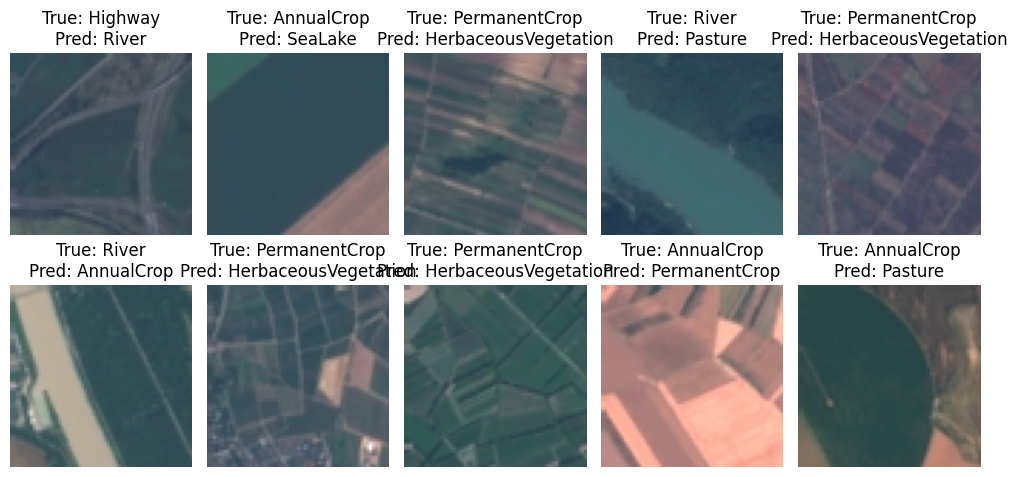

In [ ]:
# Find misclassified indices
misclassified_idx = np.where(y_true_labels != y_pred_labels)[0]

# Show some misclassified images
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i, ax in enumerate(axes.flat):
    idx = misclassified_idx[i]
    ax.imshow(X_test_rgb[idx])  # Display image
    ax.set_title(f"True: {class_names[y_true_labels[idx]]}\nPred: {class_names[y_pred_labels[idx]]}")
    ax.axis("off")
plt.tight_layout()
plt.show()


### 3.3 Multispectral Images

While the VGG16 model achieved the highest accuracy, it cannot be applied to multispectral images because it relies on **pre-trained ImageNet weights**, which are designed specifically for RGB images.

Instead, we applied our second-best model, Model, to multispectral images, modifying only the input shape to accommodate additional spectral bands. **Model 6 (Multispectral CNN)** achieved an accuracy of **79.4%**, representing a **0.8 percentage point improvement** over Model 4. This suggests that the added spectral information contributed to better class separation, though the impact was relatively modest.

In theory, multispectral data should enhance classification by distinguishing between visually similar land cover types, such as **vegetation and crop fields**. At the same time, **Shortwave Infrared (SWIR) bands** can help differentiate **water bodies from bare soil** [source](https://eos.com/blog/multispectral-vs-hyperspectral-imaging/).

The limited performance gain suggests that the architecture of Model 4 does not fully exploit the additional spectral features. Increasing the complexity of the CNN could improve its ability to capture spectral variations more effectively. Additionally, Model 6 utilized all available spectral bands, but not all bands may contribute meaningfully to classification. A more selective approach to band selection, focusing on the most relevant spectral bands, could further enhance model performance.

In [ ]:
# Load Multispectral Images
images_multispectral = []
labels_multispectral = []

for class_idx, class_name in enumerate(class_names):
    class_folder = os.path.join(data_dir, class_name)
    for filename in os.listdir(class_folder):
        img_path = os.path.join(class_folder, filename)

        with rasterio.open(img_path) as src:
            img_array = src.read()  # Read all available bands
            img_array = np.transpose(img_array, (1, 2, 0))  # Reshape to (64, 64, num_bands)
            img_array = img_array / 255.0  # Normalize

        images_multispectral.append(img_array)
        labels_multispectral.append(class_idx)

X_multispectral = np.array(images_multispectral)  # Shape: (n, 64, 64, num_bands)
y_multispectral = np.array(labels_multispectral)

/usr/local/lib/python3.11/dist-packages/rasterio/__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Train Test Split
X_train_ms, X_test_ms, y_train_ms, y_test_ms = train_test_split(
    X_multispectral, to_categorical(y_multispectral, num_classes=len(class_names)),
    test_size=0.4, stratify=y_multispectral, random_state=42
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

num_bands = X_multispectral.shape[-1]  # Number of spectral bands used

model_ms = Sequential([
    Input(shape=(64, 64, num_bands)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(len(class_names), activation='softmax')
])

model_ms.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_ms.summary()

history6 = model_ms.fit(X_train_ms, y_train_ms, epochs=10, batch_size=32, validation_data=(X_test_ms, y_test_ms))
test_loss6, test_acc6 = model_ms.evaluate(X_test_ms, y_test_ms)
print("CNN Model (Multispectrual) Accuracy:", test_acc6)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)                    │ (None, 62, 62, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 31, 31, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 29, 29, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 14, 14, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 128)                 │       1,605,760 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,626,442 (6.20 MB)

 Trainable params: 1,626,442 (6.20 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 12s 16ms/step - accuracy: 0.2948 - loss: 1.8248 - val_accuracy: 0.5552 - val_loss: 1.3004
Epoch 2/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.5644 - loss: 1.2008 - val_accuracy: 0.6660 - val_loss: 0.9597
Epoch 3/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.6585 - loss: 0.9596 - val_accuracy: 0.7281 - val_loss: 0.7485
Epoch 4/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7226 - loss: 0.8022 - val_accuracy: 0.7620 - val_loss: 0.6764
Epoch 5/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7416 - loss: 0.7452 - val_accuracy: 0.7619 - val_loss: 0.6537
Epoch 6/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7492 - loss: 0.7100 - val_accuracy: 0.7767 - val_loss: 0.6320
Epoch 7/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7686 - loss: 0.6577 - val_accuracy: 0.7816 - val_loss: 0.5987
Epoch 8/10
507/507 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7847 - loss: 0.6107 - val_accuracy: 

## 4. Reflection Questions

Tuning model parameters had a clear impact on a model's classification accuracy. The deeper and more complex models generally performed better but took longer and computing power to train. For instance, increasing training epochs would increase our model accuracy, but we kept our epochs low due to time and computing constraints.

Working with dropouts helped reduce overfitting. However, setting the dropout rate also impeded the performance of our models, as useful information was likely dropped during training.

The ensemble model, a combination of Models 1 to 3, had a slightly higher accuracy than the individual models. This shows the benefits of averaging out individual model errors. However, considering the limited improvements and low overall accuracy, the ensemble model would have performed better with stronger base models.

A key challenge was processing and training on multispectral data, which introduced more features and computation. While adding spectral bands improved the model's accuracy marginally, it was clear that our model could be enhanced to take advantage of the multispectral bands.

This assignment taught us valuable skills that will help us with other deep learning tasks moving forward. When working with a new model, tune carefully, manage overfitting with dropout, and appropriately tailor model complexity to the data and resources. Regardless of the use case, smart data processing and well-chosen architectures can vastly impact the outcomes.

### 4.1 Acknowledgements
Our code was written with the assistance of various resources. These resources include class resources, Xiaojiang Li’s lecture on Neural Networks, online resources like Stack Overflow for problem shooting, and ChatGPT.